# Crowd Counting (CSRNet) + Forecasting (LSTM) — optimised pipeline

**What this notebook does**

1. **Stage 1 – CSRNet** counts people in an image (density-map regression, ShanghaiTech Part B).
2. **Stage 2 – LSTM** forecasts the *next* crowd count from the last 24 CSRNet counts.
3. **Use case: CSRNet vs CSRNet + LSTM** – CSRNet alone is *reactive* (it only tells you the crowd right now). CSRNet + LSTM is *predictive* (it warns before the crowd crosses a risk threshold).
4. Exports `csrnet_model.pth`, `lstm_model.pth`, `lstm_scaler.json` in the exact format the FastAPI backend already loads.

**Why the original run gave bad results (all fixed below)**

| # | Problem in the old notebook | Effect | Fix |
|---|---|---|---|
| 1 | VGG16 frontend was created with `weights=None` and the pretrained weights were **never loaded** | CSRNet trained from random init on 400 images → counts ~50 % too low (see old `crowd_counts.csv`) | Load ImageNet VGG16 weights |
| 2 | No ImageNet normalisation at training time, but the backend normalises at inference | Train/serve mismatch | Normalise identically in training and backend |
| 3 | Adam `lr=1e-5` for *everything*, no schedule, only 3 of 35 epochs actually ran | Backend (random init, std 0.01) barely moved | Separate LRs (frontend small / backend larger), warm-up + cosine |
| 4 | No augmentation, full 768×1024 images, batch 8 | Overfits, slow (1.3 s/it) | Random crops + flip + colour jitter, mixed precision |
| 5 | Evaluated & exported the CSV on the **training** set, `shuffle=True` | Metrics meaningless, CSV order random | Held-out validation split + untouched test set, ordered CSV |
| 6 | Loss printed as a **sum** over batches; `loss_history` was `...` (never recorded) | No usable loss curve | Per-epoch train/val loss, val MAE, LR recorded |
| 7 | `DataParallel` then `model.state_dict()` → keys prefixed `module.` | **Backend cannot load the checkpoint** | Single model, save plain `state_dict` |
| 8 | Cells 17-21 use undefined variables (`gru_model`, `counts_scaled`, …); CSRNet & LSTM curves used the *same* `train_losses` | Notebook crashes / misleading plots | One clean, linear pipeline |
| 9 | LSTM was a 20-feature bidirectional+attention model; backend expects a **univariate** `lstm` + `fc` model | Not deployable | Univariate `CrowdLSTM` matching the backend |
| 10 | `EarlyStopping` stored `state_dict().copy()` (shallow) → "best" model was really the last one | Early stopping did nothing | `copy.deepcopy` |
| 11 | LSTM was trained on synthetic footfall unrelated to CSRNet | CSRNet and LSTM never connected | LSTM trained on the *counts CSRNet produces* |

**Run-2 optimisations (this revision, on top of the run-1 fixes)**

| Area | Change | Why |
|---|---|---|
| CSRNet data | Train on **Part A + Part B** (700 imgs), geometry-adaptive kernels for A, crops padded when images are small | 75 % more data and dense crowds, closer to temple scenes |
| CSRNet weights | **EMA** of weights, model chosen on relative val-MAE per part | Run-1 val-MAE jumped between 7 and 50 from epoch to epoch (LR noise) |
| CSRNet inference | **Flip test-time augmentation** | Cheap error reduction at inference |
| CSRNet schedule | 100 epochs (cosine) | Curve was still improving |
| LSTM data | 365 simulated days instead of 90 | Run-1 LSTM early-stopped at epoch 46 with val > train (data-starved) |
| LSTM model | Automatic **ablation of 5 variants**: univariate / +residual output / +time-of-day features / both / +peak-weighted loss; best chosen on validation loss | Run-1 seasonal-naive caught more surge onsets than the LSTM |

> **Honesty note:** ShanghaiTech is a set of independent still images – it has no time axis. Stage 2 therefore builds a *simulated* temporal stream (temple-style daily/weekly/festival pattern → for every time step the test image with the closest true count is "seen" by CSRNet). CSRNet's real, imperfect counts form the series the LSTM learns from. Replace it with real camera counts as soon as you have them.

## 0. Inputs — attach these before *Run All* (fresh Kaggle notebook)

In the notebook's right sidebar choose **+ Add Input** and add:

| Input | Type | Kaggle handle | Used for |
|---|---|---|---|
| ShanghaiTech crowd dataset (Part A + B) | Dataset | `vikasn2006/shanghai-crowd` | training / test images + head annotations |
| VGG16 ImageNet weights | Model (PyTorch, default, v1) | `vikasn2006/vgg-pretrained-weights-01` → `vgg16-397923af.pth` | pretrained CSRNet frontend |

Also set **Accelerator = GPU T4**. If you forget an input, the cell below tries to download it with `kagglehub` (needs *Settings → Internet: On*); otherwise it stops and tells you what is missing.

In [2]:
import os, glob
from pathlib import Path

DATASET_HANDLE = "vikasn2006/shanghai-crowd"
VGG_MODEL_HANDLE = "vikasn2006/vgg-pretrained-weights-01/pytorch/default/1"

def first(patterns):
    for p in patterns:
        hits = sorted(glob.glob(p, recursive=True))
        if hits: return hits[0]

def tree(root, depth=3):
    root = Path(root)
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if len(rel.parts) <= depth and (p.is_dir() or len(rel.parts) <= 2): print("  " * (len(rel.parts) - 1) + ("[dir] " if p.is_dir() else "") + p.name)

if os.path.isdir("/kaggle/input"):
    print("/kaggle/input contains:"); tree("/kaggle/input", 3)

# ---- ShanghaiTech dataset (needs part_A and part_B)
data_root = os.environ.get("CROWD_DATA")
if not data_root:
    hit = first(["/kaggle/input/**/ShanghaiTech/part_A", "archive/ShanghaiTech/part_A", "kaggle_model/archive/ShanghaiTech/part_A"])
    if hit: data_root = str(Path(hit).parents[1])
if not data_root:
    try:
        import kagglehub
        print("dataset not attached -> downloading", DATASET_HANDLE)
        path = kagglehub.dataset_download(DATASET_HANDLE)
        hit = first([f"{path}/**/ShanghaiTech/part_A"])
        if hit: data_root = str(Path(hit).parents[1])
    except Exception as e:
        print("kagglehub dataset download failed:", repr(e)[:200])
if not data_root:
    raise FileNotFoundError(f"ShanghaiTech not found. Use + Add Input -> Dataset -> '{DATASET_HANDLE}' (or turn Internet on).")
os.environ["CROWD_DATA"] = data_root
for part in "AB":
    for split in ("train_data", "test_data"):
        n = len(glob.glob(f"{data_root}/ShanghaiTech/part_{part}/{split}/images/*.jpg"))
        print(f"  part_{part}/{split}: {n} images"); assert n > 0, f"part_{part}/{split} has no images"

# ---- VGG16 ImageNet weights
vgg = os.environ.get("CROWD_VGG_WEIGHTS") or first(["/kaggle/input/**/vgg16*.pth", "**/vgg16-397923af.pth"])
if not vgg:
    try:
        import kagglehub
        print("VGG weights not attached -> downloading", VGG_MODEL_HANDLE)
        vgg = first([f"{kagglehub.model_download(VGG_MODEL_HANDLE)}/**/*.pth"])
    except Exception as e:
        print("kagglehub model download failed:", repr(e)[:200])
if vgg:
    os.environ["CROWD_VGG_WEIGHTS"] = vgg
    print("VGG16 weights:", vgg)
else:
    print("WARNING: no local VGG16 weights; torchvision will try to download them (needs Internet: On). "
          f"Best fix: + Add Input -> Models -> '{VGG_MODEL_HANDLE.rsplit('/', 3)[0]}'.")
print("\nDATA_ROOT =", data_root)

/kaggle/input contains:
dataset not attached -> downloading vikasn2006/shanghai-crowd
  part_A/train_data: 300 images
  part_A/test_data: 182 images
  part_B/train_data: 400 images
  part_B/test_data: 316 images
VGG weights not attached -> downloading vikasn2006/vgg-pretrained-weights-01/pytorch/default/1
VGG16 weights: /kaggle/input/models/vikasn2006/vgg-pretrained-weights-01/pytorch/default/1/vgg16-397923af.pth

DATA_ROOT = /kaggle/input/datasets/vikasn2006/shanghai-crowd


In [3]:
import os, sys, json, glob, math, random, time, copy, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.models import vgg16
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ----------------------------------------------------------------- config
SMOKE = os.environ.get("CROWD_SMOKE") == "1"      # tiny CPU run used only to test the code
SEED  = 42
PARTS = os.environ.get("CROWD_PARTS", "A,B").split(",")   # ShanghaiTech parts used for training AND testing
SIGMA_B = 15                                       # fixed gaussian sigma (px, full-res) for part B; part A uses adaptive kernels

CFG = dict(
    crop        = 128 if SMOKE else (256 if "A" in PARTS else 384),   # training crop (multiple of 8)
    batch_size  = 4   if SMOKE else 8,
    epochs      = 2   if SMOKE else 100,           # optimised run
    base_epochs = 1   if SMOKE else 30,            # original-recipe baseline (for the comparison plot)
    lr_front    = 1e-5,                            # pretrained VGG frontend -> gentle
    lr_back     = 1e-4,                            # freshly initialised backend -> larger
    count_w     = 0.01,                            # weight of the count-consistency L1 term
    val_frac    = 0.10,
    run_baseline= True,
    n_train     = 16 if SMOKE else None,           # None = use everything
    n_val       = 4  if SMOKE else None,
    n_test      = 8  if SMOKE else None,
    workers     = 0 if SMOKE else 4,
)
for k, v in CFG.items():                          # optional overrides, e.g. CROWD_EPOCHS=120
    e = os.environ.get("CROWD_" + k.upper())
    if e is not None: CFG[k] = (e.lower() in ("1", "true")) if isinstance(v, bool) else (type(v)(e) if v is not None else int(e))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print("device:", DEVICE, "| AMP:", USE_AMP, "| SMOKE:", SMOKE)

def find_data_root():
    cands = [os.environ.get("CROWD_DATA"),
             "/kaggle/input/datasets/vikasn2006/shanghai-crowd", "/kaggle/input/shanghai-crowd",
             "archive", "kaggle_model/archive", "../archive"]
    for c in cands:
        if c and all(os.path.isdir(os.path.join(c, "ShanghaiTech", f"part_{p}")) for p in PARTS):
            return c
    hits = glob.glob("/kaggle/input/**/ShanghaiTech/part_" + PARTS[0], recursive=True)
    if hits: return str(Path(hits[0]).parents[1])
    raise FileNotFoundError("ShanghaiTech folder not found - set CROWD_DATA or attach the dataset")

DATA_ROOT = find_data_root()
OUT_DIR = Path(os.environ.get("CROWD_OUT") or ("/kaggle/working" if os.path.isdir("/kaggle/working") else "outputs"))
FIG_DIR = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
print("parts:", PARTS, "| crop:", CFG["crop"]); print("data :", DATA_ROOT); print("out  :", OUT_DIR.resolve())

device: cuda | AMP: True | SMOKE: False
parts: ['A', 'B'] | crop: 256
data : /kaggle/input/datasets/vikasn2006/shanghai-crowd
out  : /kaggle/working


## 1. Data — ground-truth density maps

* Each annotated head is a point; the density map is those points blurred with a Gaussian, so **its sum equals the head count**.
* The network output is 1/8 of the input size, so targets are built directly on the 1/8 grid. Part B: points binned into 8×8 cells then blurred with a fixed `15/8` sigma. Part A (much denser, perspective-heavy): **geometry-adaptive** kernels, `sigma_i = 0.3 x mean distance to the 3 nearest heads`. Every head contributes exactly 1, so the count is exact; no resizing is needed.
* Evaluation always uses the **true annotation count** (`len(points)`), not the blurred map.

In [4]:
def load_points(mat_path):
    return loadmat(mat_path)["image_info"][0][0][0][0][0]          # (N, 2) x,y

def density_fixed(h, w, pts, sigma):                               # part B: fixed kernel
    h8, w8 = h // 8, w // 8
    grid = np.zeros((h8, w8), np.float32)
    if len(pts):
        xs = np.clip((pts[:, 0] // 8).astype(int), 0, w8 - 1)
        ys = np.clip((pts[:, 1] // 8).astype(int), 0, h8 - 1)
        np.add.at(grid, (ys, xs), 1.0)
    return gaussian_filter(grid, sigma / 8, mode="constant").astype(np.float32)

def density_adaptive(h, w, pts):                                   # part A: sigma_i = 0.3 * mean distance to 3 nearest heads
    h8, w8 = h // 8, w // 8
    grid = np.zeros((h8, w8), np.float32)
    n = len(pts)
    if n == 0: return grid
    sig = 0.3 * cKDTree(pts).query(pts, k=4)[0][:, 1:].mean(1) if n >= 4 else np.full(n, 15.0)
    for (x, y), sg in zip(pts, np.clip(sig / 8, 0.5, 8.0)):
        cx, cy = int(np.clip(x // 8, 0, w8 - 1)), int(np.clip(y // 8, 0, h8 - 1)); r = int(math.ceil(3 * sg))
        x0, x1, y0, y1 = max(cx - r, 0), min(cx + r + 1, w8), max(cy - r, 0), min(cy + r + 1, h8)
        k = np.exp(-(np.arange(x0, x1)[None, :] - cx) ** 2 / (2 * sg * sg) - (np.arange(y0, y1)[:, None] - cy) ** 2 / (2 * sg * sg))
        grid[y0:y1, x0:x1] += k / k.sum()                          # each head adds exactly 1 -> count preserved
    return grid

def build_records(part, split, limit=None):
    img_dir = f"{DATA_ROOT}/ShanghaiTech/part_{part}/{split}/images"
    gt_dir  = f"{DATA_ROOT}/ShanghaiTech/part_{part}/{split}/ground-truth"
    files = sorted(f for f in os.listdir(img_dir) if f.lower().endswith(".jpg"))
    if limit: files = files[:limit]
    recs = []
    for f in tqdm(files, desc=f"{part}/{split}"):
        pts = load_points(os.path.join(gt_dir, "GT_" + f.rsplit(".", 1)[0] + ".mat"))
        h, w = cv2.imread(os.path.join(img_dir, f)).shape[:2]
        dens = density_adaptive(h, w, pts) if part == "A" else density_fixed(h, w, pts, SIGMA_B)
        recs.append(dict(path=os.path.join(img_dir, f), name=f, part=part, count=float(len(pts)), density=dens))
    return recs

all_train, test_by_part = [], {}
for p in PARTS:
    all_train += build_records(p, "train_data", CFG["n_train"])
    test_by_part[p] = build_records(p, "test_data", CFG["n_test"])

rng = np.random.RandomState(SEED); perm = rng.permutation(len(all_train))
n_val = CFG["n_val"] or max(1, int(len(all_train) * CFG["val_frac"]))
val_recs   = [all_train[i] for i in perm[:n_val]]
train_recs = [all_train[i] for i in perm[n_val:]]
print(f"train {len(train_recs)} | val {len(val_recs)} | test " + " ".join(f"{p}:{len(v)}" for p, v in test_by_part.items()))
for p in PARTS:
    r = next(r for r in train_recs if r["part"] == p); print(f"sanity part {p}: gt count {r['count']:.0f} | density-map sum {r['density'].sum():.1f}")

A/train_data:   0%|          | 0/300 [00:00<?, ?it/s]

A/test_data:   0%|          | 0/182 [00:00<?, ?it/s]

B/train_data:   0%|          | 0/400 [00:00<?, ?it/s]

B/test_data:   0%|          | 0/316 [00:00<?, ?it/s]

train 630 | val 70 | test A:182 B:316
sanity part A: gt count 371 | density-map sum 371.0
sanity part B: gt count 42 | density-map sum 41.7


In [5]:
IM_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IM_STD  = np.array([0.229, 0.224, 0.225], np.float32)

def to_tensor(img_rgb):                                   # same normalisation the backend applies
    x = (img_rgb.astype(np.float32) / 255. - IM_MEAN) / IM_STD
    return torch.from_numpy(np.ascontiguousarray(x.transpose(2, 0, 1)))

class CrowdDS(Dataset):
    # train=True -> random crop (+ optional flip / colour jitter); train=False -> full image
    def __init__(self, recs, train, crop=None, augment=True):
        self.recs, self.train, self.crop, self.augment = recs, train, crop, augment
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = cv2.cvtColor(cv2.imread(r["path"]), cv2.COLOR_BGR2RGB)
        dens = r["density"]; h8, w8 = dens.shape
        img = img[:h8 * 8, :w8 * 8]
        if self.train:
            c8 = self.crop // 8; ch, cw = min(c8, h8), min(c8, w8)
            y8, x8 = random.randint(0, h8 - ch), random.randint(0, w8 - cw)
            img  = img[y8*8:(y8+ch)*8, x8*8:(x8+cw)*8]
            dens = dens[y8:y8+ch, x8:x8+cw]
            if self.augment:
                if random.random() < 0.5: img, dens = img[:, ::-1], dens[:, ::-1]
                img = np.clip(img.astype(np.float32) * random.uniform(0.75, 1.25) + random.uniform(-20, 20), 0, 255)
                if random.random() < 0.1: img = np.repeat(img.mean(2, keepdims=True), 3, 2)
        x, d = to_tensor(img), torch.from_numpy(np.ascontiguousarray(dens))[None]
        if self.train and (d.shape[1] < self.crop // 8 or d.shape[2] < self.crop // 8):      # small images: zero-pad to a fixed crop
            ph, pw = self.crop // 8 - d.shape[1], self.crop // 8 - d.shape[2]
            d = F.pad(d, (0, pw, 0, ph)); x = F.pad(x, (0, pw * 8, 0, ph * 8))
        return x, d, torch.tensor(r["count"])

def make_loaders(augment=True):
    tr = DataLoader(CrowdDS(train_recs, True, CFG["crop"], augment), batch_size=CFG["batch_size"], shuffle=True,
                    num_workers=CFG["workers"], pin_memory=DEVICE.type == "cuda", drop_last=True)
    return tr, eval_loader(val_recs)
def eval_loader(recs):
    return DataLoader(CrowdDS(recs, False), batch_size=1, shuffle=False, num_workers=min(2, CFG["workers"]))

## 2. Model — CSRNet with a properly pretrained frontend

The layer layout is identical to the backend (`frontend.*` = first 23 VGG16 layers, `backend.*` = 4 dilated convs + 1×1 output), so the checkpoint loads with `strict=True` there.

Set `VGG_WEIGHTS_PATH` (env var or below) if the Kaggle notebook has no internet: attach a dataset containing torchvision's `vgg16-397923af.pth`, otherwise enable *Settings → Internet*.

In [6]:
VGG_WEIGHTS_PATH = os.environ.get("CROWD_VGG_WEIGHTS")     # optional local file

def build_vgg16(pretrained):
    net = vgg16(weights=None)
    if not pretrained: return net
    paths = [VGG_WEIGHTS_PATH] + glob.glob("/kaggle/input/**/vgg16*.pth", recursive=True)
    for p in paths:
        if p and os.path.exists(p):
            net.load_state_dict(torch.load(p, map_location="cpu")); print("VGG16 ImageNet weights <-", p); return net
    try:
        from torchvision.models import VGG16_Weights
        net = vgg16(weights=VGG16_Weights.IMAGENET1K_V1); print("VGG16 ImageNet weights downloaded"); return net
    except Exception as e:
        raise RuntimeError("Could not obtain pretrained VGG16 (this is THE fix for bad accuracy). "
                           "Enable Internet in Kaggle settings or attach a vgg16 weights dataset.") from e

class CSRNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.frontend = build_vgg16(pretrained).features[:23]
        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(128,  64, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1))
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01); nn.init.zeros_(m.bias)
    def forward(self, x): return self.backend(self.frontend(x))

@torch.no_grad()
def evaluate(model, loader, recs, tta=False):
    # full-resolution evaluation against the TRUE annotation count; tta = average with horizontally flipped input
    model.eval(); preds, gts, mse = [], [], []
    for x, d, c in loader:
        x = x.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            out = model(x)
            if tta: out = (out + model(x.flip(-1)).flip(-1)) / 2
        out = out.float()
        preds.append(max(out.sum().item(), 0.0)); gts.append(c.item())
        mse.append(F.mse_loss(out, d.to(DEVICE)).item())
    p, g = np.array(preds), np.array(gts); parts = np.array([r["part"] for r in recs])
    rel = np.mean([np.abs(p[parts == q] - g[parts == q]).mean() / max(g[parts == q].mean(), 1) for q in np.unique(parts)])
    return dict(mse=float(np.mean(mse)), mae=float(np.mean(np.abs(p - g))), rmse=float(np.sqrt(np.mean((p - g) ** 2))), rel=float(rel)), p, g

## 3. Training

Same function trains both the **original recipe** (random VGG init, Adam 1e-5 for every layer, MSE only, no flip/colour augmentation, constant LR) and the **optimised recipe**, on identical crops, so the loss curves are a fair before/after.

Optimisations in the optimised run: pretrained frontend · separate LRs · warm-up + cosine decay · flip & colour jitter · count-consistency loss · mixed precision · gradient clipping · **EMA weights** · best checkpoint chosen on the **validation** relative-MAE (mean over parts of MAE / mean count, so dense Part A does not drown out Part B).

In [7]:
def train_csrnet(name, pretrained, lr_front, lr_back, augment, epochs, count_w, schedule, use_ema=False, ema_decay=0.995):
    torch.manual_seed(SEED); random.seed(SEED)
    model = CSRNet(pretrained).to(DEVICE)
    opt = torch.optim.Adam([{"params": model.frontend.parameters(), "lr": lr_front},
                            {"params": model.backend.parameters(),  "lr": lr_back}], weight_decay=1e-5)
    warm = max(1, epochs // 20)
    lam = (lambda e: min(1.0, (e + 1) / warm) * (0.02 + 0.98 * 0.5 * (1 + math.cos(math.pi * e / epochs)))) if schedule else (lambda e: 1.0)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lam)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    tr_loader, va_loader = make_loaders(augment)
    ema = copy.deepcopy(model) if use_ema else None; step = 0
    hist, best, best_state = [], float("inf"), None
    for ep in range(epochs):
        model.train(); t0 = time.time(); tl, tm = 0.0, 0.0
        for x, d, c in tr_loader:
            x, d, c = x.to(DEVICE, non_blocking=True), d.to(DEVICE, non_blocking=True), c.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                out = model(x)
            out = out.float()
            loss = F.mse_loss(out, d, reduction="sum") / x.size(0)
            if count_w: loss = loss + count_w * (out.sum((1, 2, 3)) - d.sum((1, 2, 3))).abs().mean()
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update()
            if use_ema:
                step += 1; dcy = min(ema_decay, (1 + step) / (10 + step))
                with torch.no_grad():
                    for pe, pm in zip(ema.parameters(), model.parameters()): pe.mul_(dcy).add_(pm.detach(), alpha=1 - dcy)
            tl += loss.item(); tm += F.mse_loss(out, d).item()
        sched.step()
        ev_model = ema if use_ema else model
        v, _, _ = evaluate(ev_model, va_loader, val_recs)
        rec = dict(epoch=ep + 1, train_loss=tl / len(tr_loader), train_mse=tm / len(tr_loader),
                   val_mse=v["mse"], val_mae=v["mae"], val_rmse=v["rmse"], val_rel=v["rel"], lr=opt.param_groups[1]["lr"])
        hist.append(rec)
        if v["rel"] < best:
            best = v["rel"]; best_state = {k: t.detach().cpu().clone() for k, t in ev_model.state_dict().items()}
        if ep % max(1, epochs // 20) == 0 or ep == epochs - 1:
            print(f"[{name}] ep {ep+1:3d}/{epochs} train_mse {rec['train_mse']:.5f} val_mse {rec['val_mse']:.5f} "
                  f"val_MAE {v['mae']:6.2f} val_rel {v['rel']:.3f} best_rel {best:.3f} ({time.time()-t0:.0f}s/ep)")
    final = ema if use_ema else model
    final.load_state_dict(best_state)
    return final, pd.DataFrame(hist)

hist_base = None
if CFG["run_baseline"]:
    print("=== ORIGINAL RECIPE (random init, Adam 1e-5, MSE only, no aug, constant LR) ===")
    base_model, hist_base = train_csrnet("baseline", pretrained=False, lr_front=1e-5, lr_back=1e-5, augment=False,
                                         epochs=CFG["base_epochs"], count_w=0.0, schedule=False)

=== ORIGINAL RECIPE (random init, Adam 1e-5, MSE only, no aug, constant LR) ===
[baseline] ep   1/30 train_mse 0.01606 val_mse 0.02050 val_MAE 305.15 val_rel 1.643 best_rel 1.643 (13s/ep)
[baseline] ep   2/30 train_mse 0.01857 val_mse 0.01735 val_MAE 180.64 val_rel 0.616 best_rel 0.616 (9s/ep)
[baseline] ep   3/30 train_mse 0.01503 val_mse 0.01667 val_MAE 193.64 val_rel 0.796 best_rel 0.616 (9s/ep)
[baseline] ep   4/30 train_mse 0.01555 val_mse 0.01732 val_MAE 174.11 val_rel 0.616 best_rel 0.616 (9s/ep)
[baseline] ep   5/30 train_mse 0.01426 val_mse 0.01664 val_MAE 158.39 val_rel 0.495 best_rel 0.495 (9s/ep)
[baseline] ep   6/30 train_mse 0.01374 val_mse 0.01794 val_MAE 181.20 val_rel 0.546 best_rel 0.495 (9s/ep)
[baseline] ep   7/30 train_mse 0.01434 val_mse 0.01755 val_MAE 182.24 val_rel 0.532 best_rel 0.495 (9s/ep)
[baseline] ep   8/30 train_mse 0.01526 val_mse 0.01560 val_MAE 150.41 val_rel 0.515 best_rel 0.495 (9s/ep)
[baseline] ep   9/30 train_mse 0.01500 val_mse 0.01598 val_MAE 

In [8]:
print("=== OPTIMISED RECIPE ===")
model, hist_opt = train_csrnet("optimised", pretrained=True, lr_front=CFG["lr_front"], lr_back=CFG["lr_back"],
                               augment=True, epochs=CFG["epochs"], count_w=CFG["count_w"], schedule=True, use_ema=True)
hist_opt.to_csv(OUT_DIR / "csrnet_history_optimised.csv", index=False)
if hist_base is not None: hist_base.to_csv(OUT_DIR / "csrnet_history_baseline.csv", index=False)

=== OPTIMISED RECIPE ===
VGG16 ImageNet weights <- /kaggle/input/models/vikasn2006/vgg-pretrained-weights-01/pytorch/default/1/vgg16-397923af.pth
[optimised] ep   1/100 train_mse 0.01516 val_mse 0.01531 val_MAE 116.68 val_rel 0.328 best_rel 0.328 (10s/ep)
[optimised] ep   6/100 train_mse 0.00950 val_mse 0.01068 val_MAE  74.56 val_rel 0.207 best_rel 0.207 (10s/ep)
[optimised] ep  11/100 train_mse 0.00835 val_mse 0.00965 val_MAE  60.98 val_rel 0.185 best_rel 0.185 (10s/ep)
[optimised] ep  16/100 train_mse 0.00735 val_mse 0.00942 val_MAE  60.14 val_rel 0.178 best_rel 0.178 (10s/ep)
[optimised] ep  21/100 train_mse 0.00762 val_mse 0.00963 val_MAE  65.07 val_rel 0.185 best_rel 0.178 (10s/ep)
[optimised] ep  26/100 train_mse 0.00806 val_mse 0.00939 val_MAE  63.35 val_rel 0.175 best_rel 0.175 (10s/ep)
[optimised] ep  31/100 train_mse 0.00699 val_mse 0.00950 val_MAE  65.75 val_rel 0.178 best_rel 0.175 (10s/ep)
[optimised] ep  36/100 train_mse 0.00678 val_mse 0.00952 val_MAE  66.08 val_rel 0.18

## 4. Loss graphs — CSRNet (original recipe vs optimised)

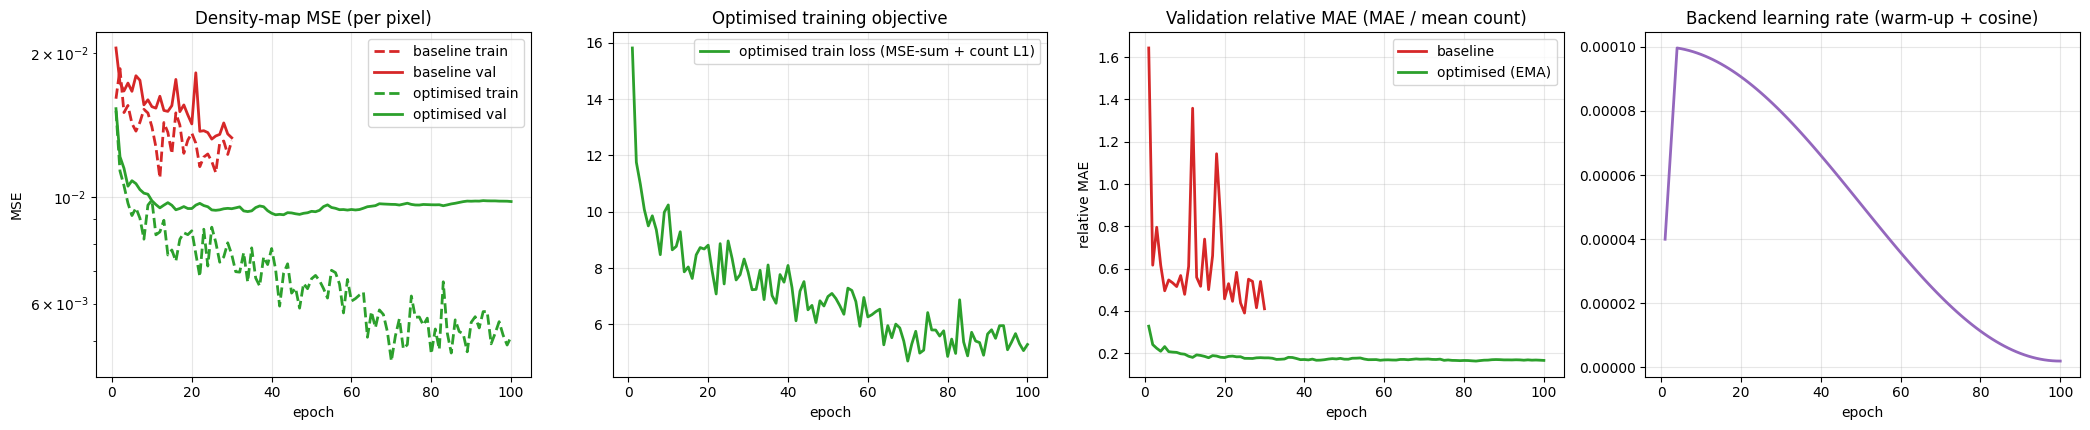

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(21, 4.4))
def curve(a, h, key, label, **kw):
    a.plot(h["epoch"], h[key], label=label, lw=2, **kw)
if hist_base is not None:
    curve(ax[0], hist_base, "train_mse", "baseline train", ls="--", color="tab:red")
    curve(ax[0], hist_base, "val_mse",   "baseline val",   color="tab:red")
    curve(ax[2], hist_base, "val_rel",   "baseline", color="tab:red")
curve(ax[0], hist_opt, "train_mse", "optimised train", ls="--", color="tab:green")
curve(ax[0], hist_opt, "val_mse",   "optimised val",   color="tab:green")
ax[0].set(title="Density-map MSE (per pixel)", xlabel="epoch", ylabel="MSE"); ax[0].set_yscale("log")
curve(ax[1], hist_opt, "train_loss", "optimised train loss (MSE-sum + count L1)", color="tab:green")
ax[1].set(title="Optimised training objective", xlabel="epoch")
curve(ax[2], hist_opt, "val_rel", "optimised (EMA)", color="tab:green")
ax[2].set(title="Validation relative MAE (MAE / mean count)", xlabel="epoch", ylabel="relative MAE")
ax[3].plot(hist_opt["epoch"], hist_opt["lr"], color="tab:purple", lw=2)
ax[3].set(title="Backend learning rate (warm-up + cosine)", xlabel="epoch")
for a in ax: a.grid(alpha=.3); a.legend() if a.get_legend_handles_labels()[0] else None
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_loss_curves.png", dpi=150); plt.show()

## 5. CSRNet test results (held-out test sets, never used for training or model selection)

                                   MAE     RMSE    MAPE     R2
Part A | optimised (EMA)        71.212  116.166  16.711  0.892
Part A | optimised + flip-TTA   71.115  116.188  16.725  0.892
Part A | original recipe       166.033  232.926  50.912  0.566
Part B | optimised (EMA)        12.905   24.636  10.386  0.933
Part B | optimised + flip-TTA   12.704   24.219  10.187  0.935
Part B | original recipe        45.987   68.224  54.364  0.486

Reference (published CSRNet): Part A MAE 68.2 / RMSE 115.0 | Part B MAE 10.6 / RMSE 16.0  (~1000 epochs)


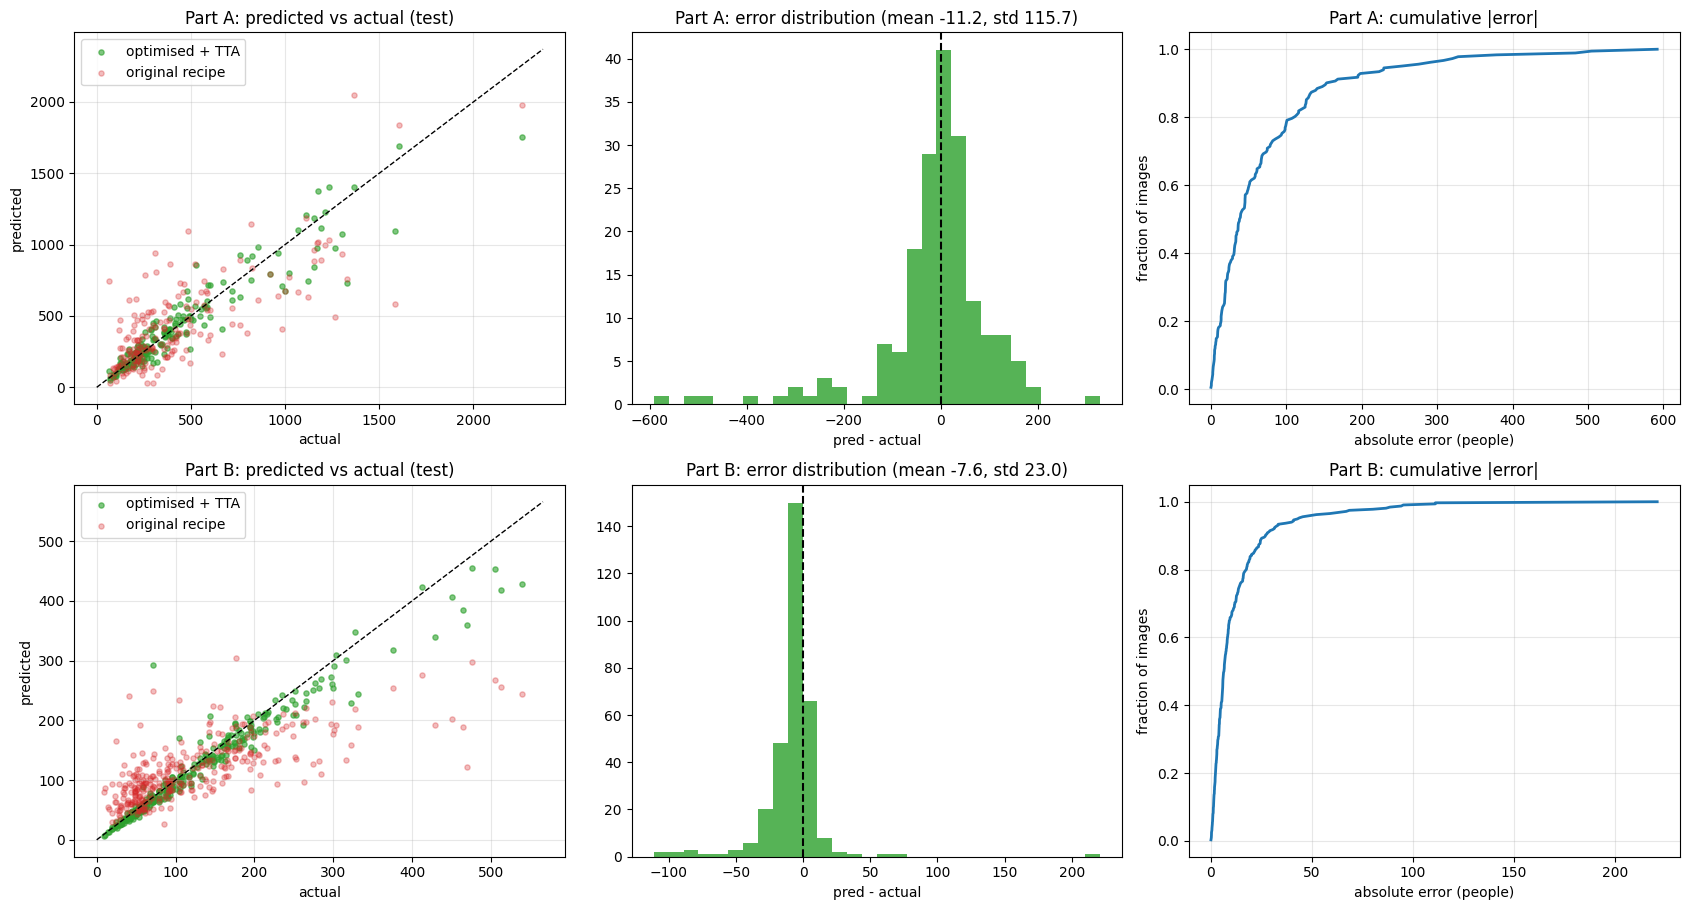

In [10]:
def metrics(p, g):
    return dict(MAE=float(np.mean(np.abs(p - g))), RMSE=float(np.sqrt(np.mean((p - g) ** 2))),
                MAPE=float(np.mean(np.abs(p - g) / np.maximum(g, 1)) * 100),
                R2=float(1 - np.sum((g - p) ** 2) / np.sum((g - g.mean()) ** 2)))

res, P = {}, {}
for p in PARTS:
    ld, recs = eval_loader(test_by_part[p]), test_by_part[p]
    _, pp, gg = evaluate(model, ld, recs);            res[f"Part {p} | optimised (EMA)"] = metrics(pp, gg)
    _, pt, _  = evaluate(model, ld, recs, tta=True);  res[f"Part {p} | optimised + flip-TTA"] = metrics(pt, gg)
    bp = None
    if hist_base is not None:
        _, bp, _ = evaluate(base_model, ld, recs);    res[f"Part {p} | original recipe"] = metrics(bp, gg)
    P[p] = dict(plain=pp, tta=pt, base=bp, gt=gg)
print(pd.DataFrame(res).T.round(3).to_string())
print("\nReference (published CSRNet): Part A MAE 68.2 / RMSE 115.0 | Part B MAE 10.6 / RMSE 16.0  (~1000 epochs)")

fig, ax = plt.subplots(len(PARTS), 3, figsize=(17, 4.6 * len(PARTS)), squeeze=False)
for row, p in enumerate(PARTS):
    d = P[p]; g = d["gt"]; best = d["tta"]
    ax[row, 0].scatter(g, best, s=14, alpha=.6, color="tab:green", label="optimised + TTA")
    if d["base"] is not None: ax[row, 0].scatter(g, d["base"], s=14, alpha=.3, color="tab:red", label="original recipe")
    lim = [0, max(g.max(), best.max()) * 1.05]; ax[row, 0].plot(lim, lim, "k--", lw=1)
    ax[row, 0].set(title=f"Part {p}: predicted vs actual (test)", xlabel="actual", ylabel="predicted"); ax[row, 0].legend(); ax[row, 0].grid(alpha=.3)
    err = best - g
    ax[row, 1].hist(err, bins=30, color="tab:green", alpha=.8); ax[row, 1].axvline(0, color="k", ls="--")
    ax[row, 1].set(title=f"Part {p}: error distribution (mean {err.mean():.1f}, std {err.std():.1f})", xlabel="pred - actual")
    ax[row, 2].plot(np.sort(np.abs(err)), np.arange(1, len(err) + 1) / len(err), color="tab:blue", lw=2)
    ax[row, 2].set(title=f"Part {p}: cumulative |error|", xlabel="absolute error (people)", ylabel="fraction of images"); ax[row, 2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_test_results.png", dpi=150); plt.show()

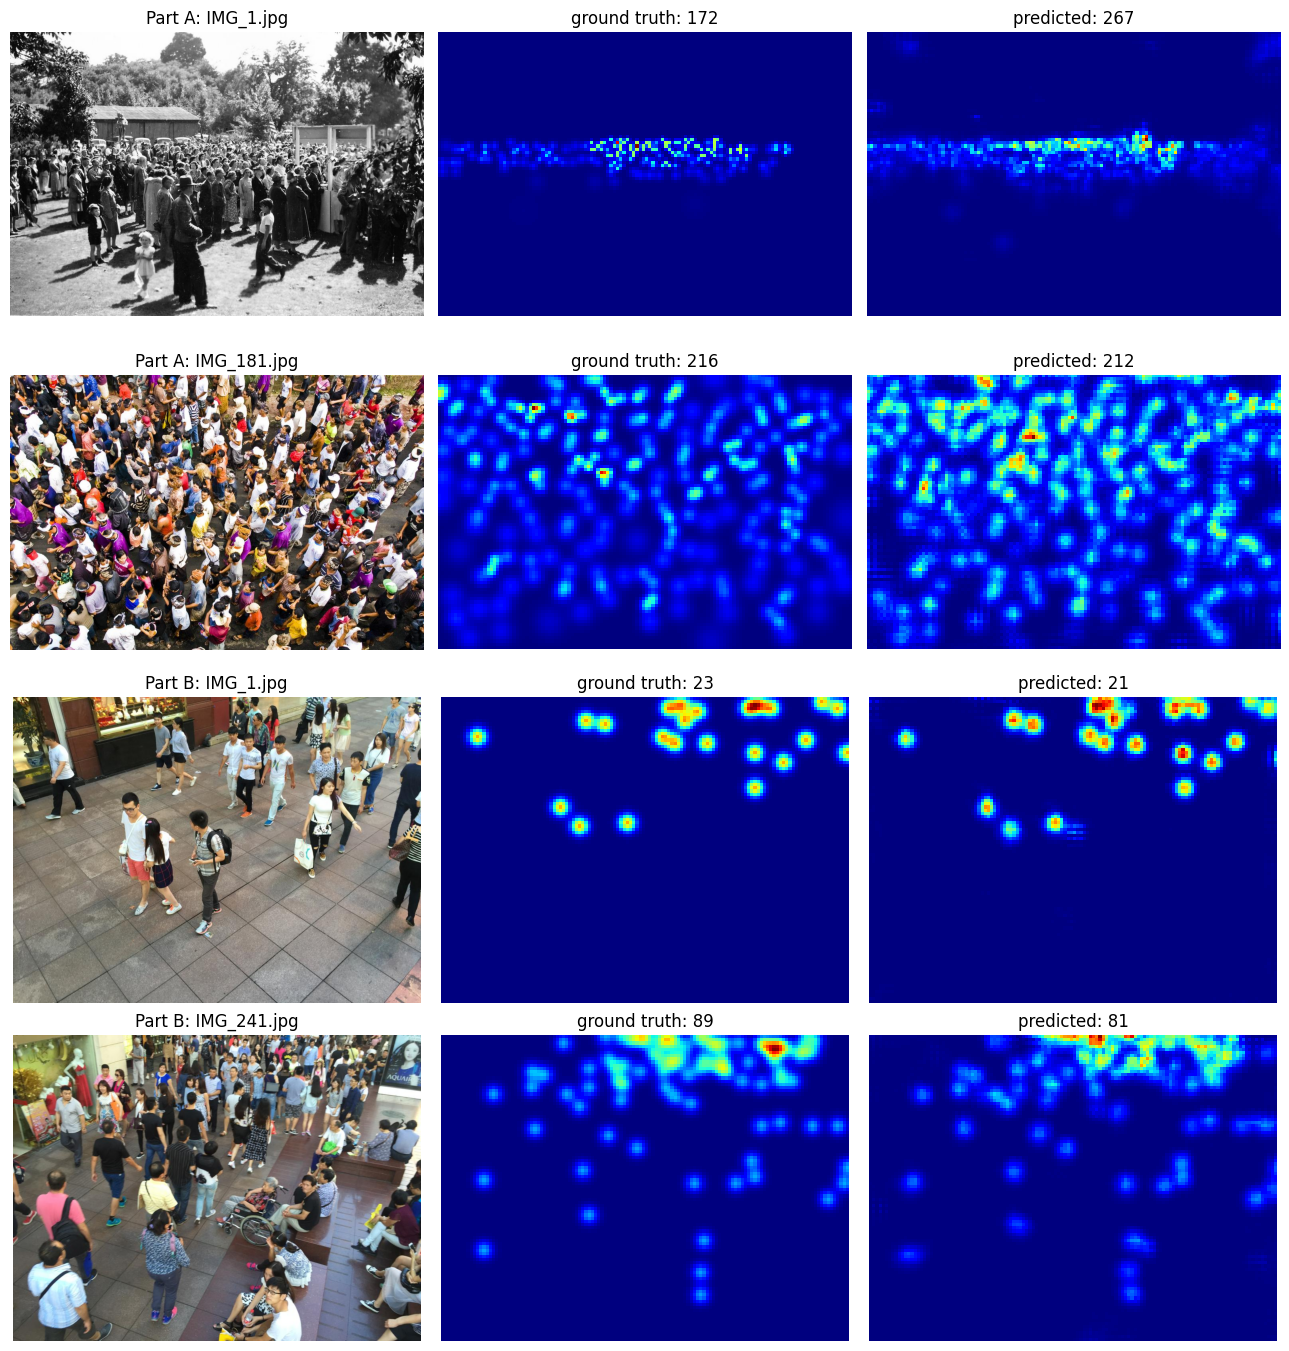

In [11]:
# Qualitative: image | ground-truth density | predicted density (2 test images per part)
sel = [(p, r) for p in PARTS for r in (test_by_part[p][0], test_by_part[p][len(test_by_part[p]) // 2])]
fig, ax = plt.subplots(len(sel), 3, figsize=(13, 3.4 * len(sel))); model.eval()
for row, (p, r) in enumerate(sel):
    img = cv2.cvtColor(cv2.imread(r["path"]), cv2.COLOR_BGR2RGB); h8, w8 = r["density"].shape
    with torch.no_grad():
        out = model(to_tensor(img[:h8*8, :w8*8])[None].to(DEVICE)).float().cpu().numpy()[0, 0]
    ax[row, 0].imshow(img); ax[row, 0].set_title(f"Part {p}: {r['name']}")
    ax[row, 1].imshow(r["density"], cmap="jet"); ax[row, 1].set_title(f"ground truth: {r['count']:.0f}")
    ax[row, 2].imshow(np.maximum(out, 0), cmap="jet"); ax[row, 2].set_title(f"predicted: {out.sum():.0f}")
    for a in ax[row]: a.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_density_samples.png", dpi=130); plt.show()

In [12]:
# Export CSRNet: plain state_dict (no 'module.' prefix) -> loads with strict=True in the backend
torch.save({k: v.cpu() for k, v in model.state_dict().items()}, OUT_DIR / "csrnet_model.pth")

# Stage-2 pool: Part B test images (sparse street scenes); prefer flip-TTA predictions if they are better
POOL = "B" if "B" in PARTS else PARTS[0]
use_tta = res[f"Part {POOL} | optimised + flip-TTA"]["MAE"] <= res[f"Part {POOL} | optimised (EMA)"]["MAE"]
test_pred, test_gt = (P[POOL]["tta"] if use_tta else P[POOL]["plain"]), P[POOL]["gt"]
print(f"stage-2 pool = Part {POOL}, predictions = {'EMA + flip-TTA' if use_tta else 'EMA'}")

pd.DataFrame({"timestamp": pd.date_range("2025-01-01 08:00:00", periods=len(test_gt), freq="1min"),
              "image_id": np.arange(len(test_gt)), "predicted_count": test_pred, "actual_count": test_gt}
             ).to_csv(OUT_DIR / "crowd_counts.csv", index=False)
json.dump(res, open(OUT_DIR / "csrnet_results.json", "w"), indent=2)
print("saved csrnet_model.pth, crowd_counts.csv, csrnet_results.json")

stage-2 pool = Part B, predictions = EMA + flip-TTA
saved csrnet_model.pth, crowd_counts.csv, csrnet_results.json


## 6. Use case — CSRNet **vs** CSRNet + LSTM

* **CSRNet only (reactive):** the dashboard shows the count in the current frame. To "predict" the next hour it can only assume *nothing changes* (persistence).
* **CSRNet + LSTM (predictive):** the LSTM reads the last 24 CSRNet counts (optionally with time-of-day) and forecasts the next one, so a surge can be flagged **before** it happens.

Setup: a simulated **365-day** hourly stream (daily peaks, weekends, festivals, random spikes). At every step the test image with the closest true count is shown to CSRNet → `observed` = CSRNet's real (noisy) count, `truth` = its annotated count. The forecast target is the **true** count of the next step. Chronological 70 / 15 / 15 split.

Five LSTM variants are trained and compared; the one with the lowest **validation** loss is exported.

In [13]:
DAYS, SEQ = (20 if SMOKE else 365), 24
WARN, CRIT = 100, 200                                    # risk thresholds (people)

def hour_factor(h):
    if 6 <= h <= 9:   return 1.5 - abs(h - 7.5) * 0.3
    if 17 <= h <= 20: return 1.4 - abs(h - 18.5) * 0.25
    if 4 <= h < 6:    return 0.6
    if h >= 21 or h < 4: return 0.2
    return 0.8

def time_feats(ts):                                      # per-step hour / weekday as sin-cos (backend mirrors this exactly)
    h, d = np.asarray(ts.hour), np.asarray(ts.dayofweek)
    return np.stack([np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24),
                     np.sin(2 * np.pi * d / 7),  np.cos(2 * np.pi * d / 7)], 1).astype(np.float32)

def simulate_target(days, seed=SEED):
    rg = np.random.default_rng(seed)
    ts = pd.date_range("2024-01-01", periods=days * 24, freq="h")
    day_mult = np.where(ts.dayofweek >= 5, 1.4, np.where(ts.dayofweek == 4, 1.2, 1.0))
    fest = {d: rg.uniform(1.8, 3.0) for d in rg.choice(days, max(2, days // 25), replace=False)}
    f = np.array([hour_factor(t.hour) for t in ts]) * day_mult
    f = f * np.array([fest.get((t - ts[0]).days, 1.0) for t in ts])
    f = f * (1 + rg.uniform(-.15, .15, len(ts))) * np.where(rg.random(len(ts)) < .02, rg.uniform(1.3, 2.0, len(ts)), 1.0)
    c = f / np.percentile(f, 99) * 0.75 * test_gt.max()
    return ts, np.clip(c, test_gt.min(), test_gt.max())

ts, target = simulate_target(DAYS)
order = np.argsort(test_gt); sgt = test_gt[order]; rg = np.random.default_rng(SEED)
def pick(c):
    j = np.searchsorted(sgt, c); return rg.choice(order[max(0, j - 2): min(len(order), j + 3)])
sel = np.array([pick(c) for c in target])
observed, truth = test_pred[sel], test_gt[sel]           # what CSRNet reports vs what is really there
print(f"{len(ts)} hourly steps | truth {truth.min():.0f}-{truth.max():.0f} | CSRNet-vs-truth MAE on this stream: {np.abs(observed-truth).mean():.1f}")

n = len(ts) - SEQ
X_raw = np.stack([observed[i:i + SEQ] for i in range(n)]); y = truth[SEQ:]        # y[i] = truth at step i+SEQ
cur_truth = truth[SEQ - 1: -1]                                                    # truth at the last observed step
i_tr, i_va = int(.70 * n), int(.85 * n)
lo, hi = float(min(X_raw[:i_tr].min(), y[:i_tr].min())), float(max(X_raw[:i_tr].max(), y[:i_tr].max()))
norm = lambda a: (a - lo) / (hi - lo); denorm = lambda a: a * (hi - lo) + lo
TF = time_feats(ts); yn = norm(y).astype(np.float32)

def make_X(feats):                                       # (n, SEQ, 1) or (n, SEQ, 5) = [count, sin_h, cos_h, sin_d, cos_d]
    base = norm(observed)[:, None].astype(np.float32)
    if feats: base = np.concatenate([base, TF], 1)
    return np.stack([base[i:i + SEQ] for i in range(n)])
print("windows  train/val/test:", i_tr, i_va - i_tr, n - i_va)

8760 hourly steps | truth 24-539 | CSRNet-vs-truth MAE on this stream: 12.5
windows  train/val/test: 6115 1310 1311


In [14]:
class CrowdLSTM(nn.Module):                     # identical to backend/utils/model_defs.py (lstm + fc)
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1, residual=False):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1); self.residual = residual
    def forward(self, x):
        o, _ = self.lstm(x); out = self.fc(o[:, -1, :])
        return out + x[:, -1, :1] if self.residual else out          # residual: learn the CHANGE from the latest CSRNet count

LSTM_EPOCHS, PATIENCE = (3 if SMOKE else 200), 25

def train_lstm(name, feats, resid, wpow):
    Xn = make_X(feats); T = lambda a: torch.tensor(a, dtype=torch.float32)
    mk = lambda a, b: TensorDataset(T(Xn[a:b]), T(yn[a:b]).unsqueeze(-1))
    dl_tr = DataLoader(mk(0, i_tr), batch_size=128, shuffle=True)
    dl_va, dl_te = DataLoader(mk(i_tr, i_va), batch_size=512), DataLoader(mk(i_va, n), batch_size=512)
    torch.manual_seed(SEED)
    m = CrowdLSTM(Xn.shape[2], 64, 2, 0.1, resid).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=2e-3, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
    hist, best, best_state, bad = [], float("inf"), None, 0
    for ep in range(LSTM_EPOCHS):
        m.train(); tl = 0
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = ((1 + wpow * yb) * (m(xb) - yb) ** 2).mean()          # wpow>0 -> errors on busy hours cost more
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); tl += loss.item() * len(xb)
        m.eval()
        with torch.no_grad(): vl = sum(F.mse_loss(m(a.to(DEVICE)), b.to(DEVICE)).item() * len(a) for a, b in dl_va) / (i_va - i_tr)
        hist.append(dict(epoch=ep + 1, train_loss=tl / i_tr, val_loss=vl)); sch.step(vl)
        if vl < best - 1e-6: best, bad, best_state = vl, 0, copy.deepcopy(m.state_dict())     # deepcopy (old code kept a shallow copy)
        else:
            bad += 1
            if bad >= PATIENCE: break
    m.load_state_dict(best_state); m.eval()
    with torch.no_grad(): p = np.concatenate([m(a.to(DEVICE)).cpu().numpy() for a, _ in dl_te]).ravel()
    print(f"  {name:28s} epochs {ep+1:3d} | best val loss {best:.5f}")
    return dict(name=name, model=m, hist=pd.DataFrame(hist), val=best, pred=np.maximum(denorm(p), 0), feats=feats, resid=resid, input_size=Xn.shape[2])

VARIANTS = [("univariate (run-1)",       dict(feats=False, resid=False, wpow=0.0)),
            ("+ residual output",        dict(feats=False, resid=True,  wpow=0.0)),
            ("+ time-of-day features",   dict(feats=True,  resid=False, wpow=0.0)),
            ("+ time features + resid",  dict(feats=True,  resid=True,  wpow=0.0)),
            ("+ time + resid + peak-wt", dict(feats=True,  resid=True,  wpow=2.0))]
print("Training LSTM variants ...")
runs = [train_lstm(nm, **kw) for nm, kw in VARIANTS]
BEST = min(runs, key=lambda r: r["val"]); print("\nselected on validation loss ->", BEST["name"])
lh, p_lstm = BEST["hist"], BEST["pred"]; lh.to_csv(OUT_DIR / "lstm_history.csv", index=False)

Training LSTM variants ...
  univariate (run-1)           epochs 146 | best val loss 0.00271
  + residual output            epochs 164 | best val loss 0.00285
  + time-of-day features       epochs 166 | best val loss 0.00204
  + time features + resid      epochs 120 | best val loss 0.00206
  + time + resid + peak-wt     epochs  92 | best val loss 0.00212

selected on validation loss -> + time-of-day features


In [15]:
# Predictions on the chronological TEST windows
yt, cur, Xt = y[i_va:], cur_truth[i_va:], X_raw[i_va:]
preds = {"CSRNet only (reactive)":        Xt[:, -1],                 # persistence: next = current CSRNet count
         "CSRNet + moving avg (3h)":      Xt[:, -3:].mean(1),
         "CSRNet + seasonal (24h ago)":   Xt[:, 0],                  # same hour yesterday
         "CSRNet + LSTM (predictive)":    p_lstm}
table = pd.DataFrame({k: metrics(v, yt) for k, v in preds.items()}).T
print("Next-hour forecast vs TRUE next-hour count (chronological test windows)\n"); print(table.round(3).to_string())

level = lambda a: np.digitize(a, [WARN, CRIT])                       # 0 safe, 1 warning, 2 critical
def risk_row(v):
    tp = ((v >= CRIT) & (yt >= CRIT)).sum(); fp = ((v >= CRIT) & (yt < CRIT)).sum(); fn = ((v < CRIT) & (yt >= CRIT)).sum()
    onset = (cur < CRIT) & (yt >= CRIT)                               # crowd is still below CRIT now but crosses it next hour
    return dict(risk_acc=(level(v) == level(yt)).mean(), crit_precision=tp / max(tp + fp, 1), crit_recall=tp / max(tp + fn, 1),
                surge_onsets=int(onset.sum()), onsets_caught=int(((v >= CRIT) & onset).sum()), false_alarms=int(fp))
rows = {k: risk_row(v) for k, v in preds.items()}
risk = pd.DataFrame(rows).T; print("\nRisk / early-warning (critical >= %d people)\n" % CRIT); print(risk.round(3).to_string())
table.join(risk).to_csv(OUT_DIR / "usecase_comparison.csv")

# LSTM ablation on the same test windows
abl = pd.DataFrame({r["name"]: {**metrics(r["pred"], yt), "val_loss": r["val"], **{k: v for k, v in risk_row(r["pred"]).items() if k in ("crit_recall", "onsets_caught", "false_alarms")}} for r in runs}).T
print("\nLSTM variants (test windows)\n"); print(abl.round(4).to_string()); abl.to_csv(OUT_DIR / "lstm_variants.csv")

Next-hour forecast vs TRUE next-hour count (chronological test windows)

                                MAE    RMSE    MAPE     R2
CSRNet only (reactive)       35.158  54.106  38.745  0.536
CSRNet + moving avg (3h)     48.796  68.072  61.864  0.265
CSRNet + seasonal (24h ago)  28.818  48.637  21.650  0.625
CSRNet + LSTM (predictive)   12.110  21.819   9.802  0.924

Risk / early-warning (critical >= 200 people)

                             risk_acc  crit_precision  crit_recall  surge_onsets  onsets_caught  false_alarms
CSRNet only (reactive)          0.719           0.590        0.493          92.0            0.0          75.0
CSRNet + moving avg (3h)        0.670           0.470        0.251          92.0            1.0          62.0
CSRNet + seasonal (24h ago)     0.787           0.634        0.530          92.0           38.0          67.0
CSRNet + LSTM (predictive)      0.927           0.851        0.808          92.0           63.0          31.0

LSTM variants (test windows)

   

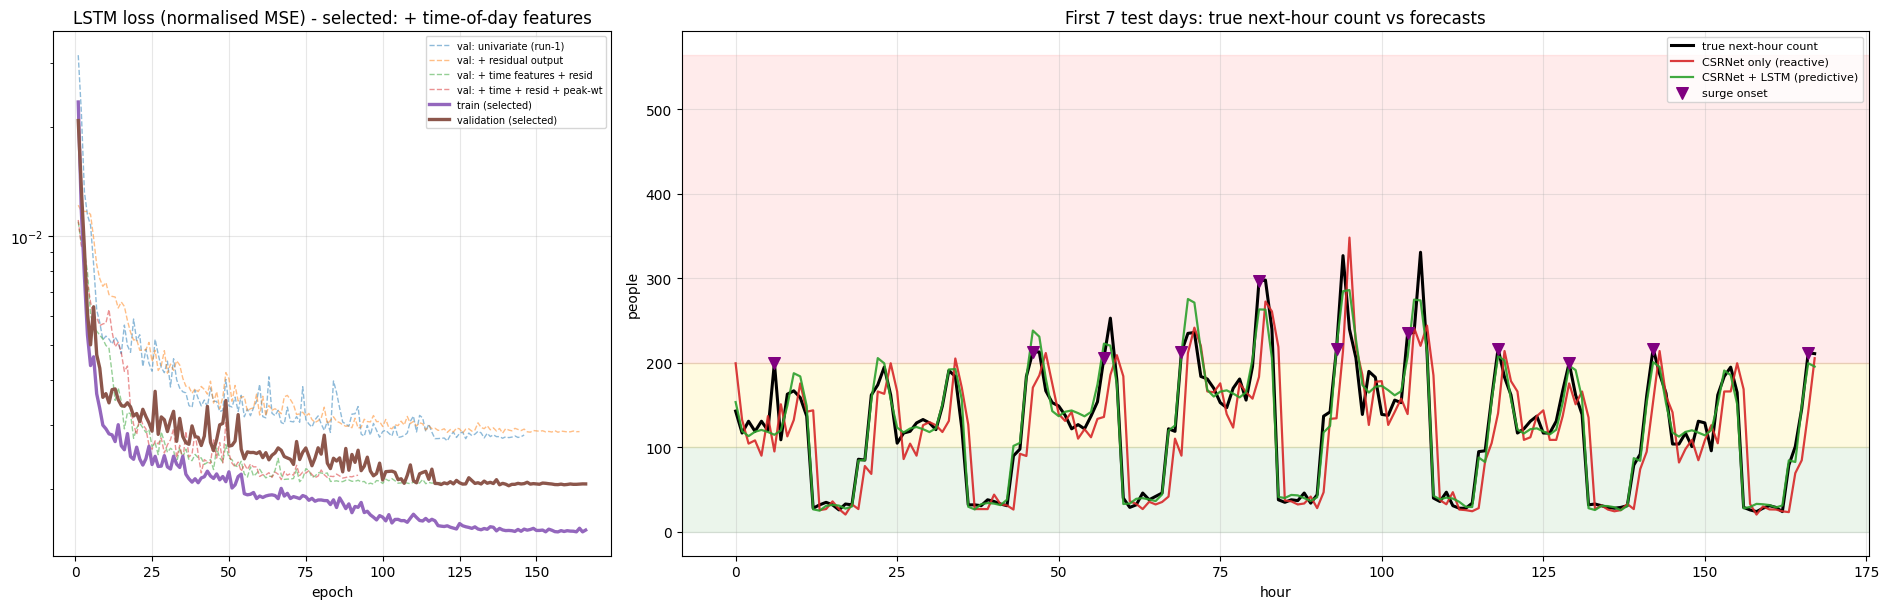

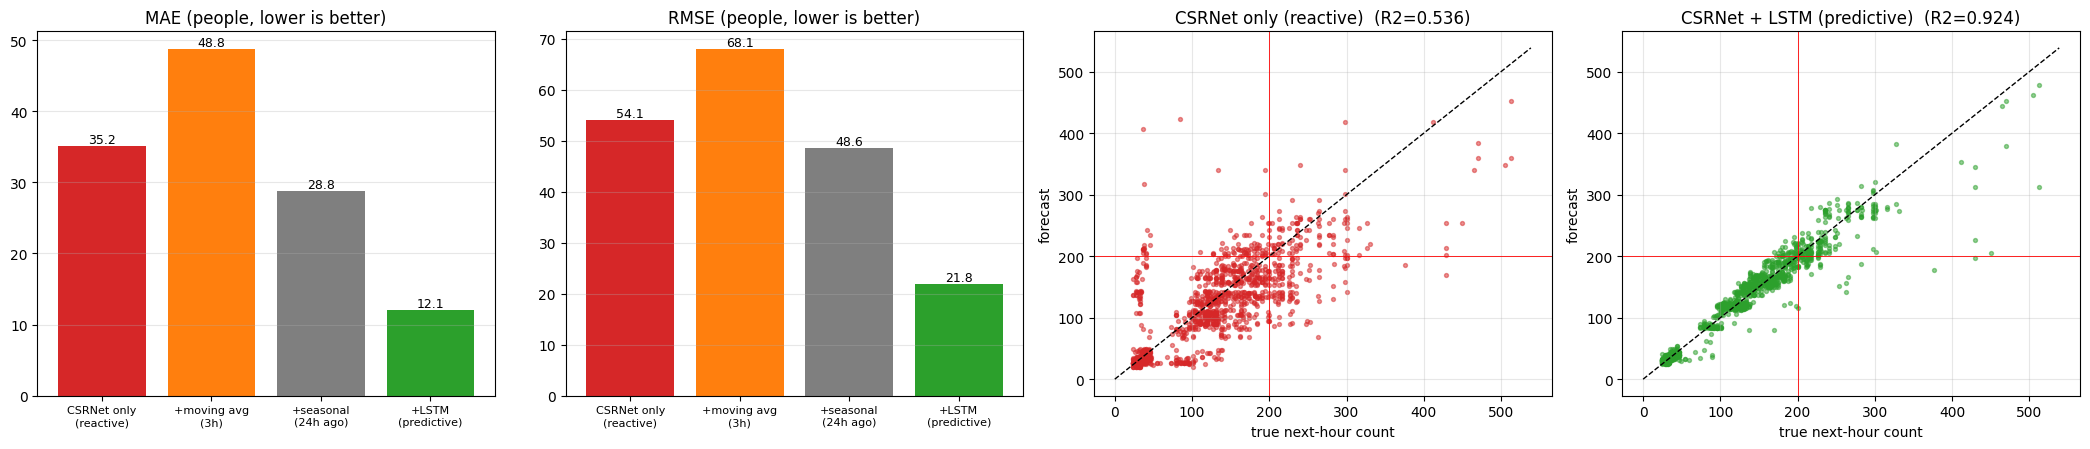

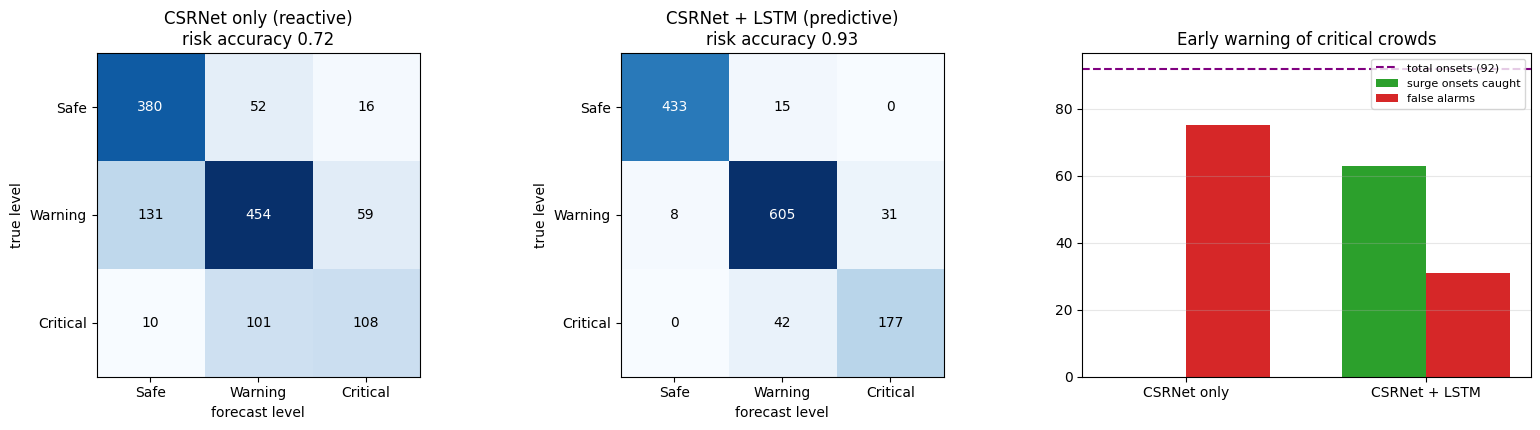

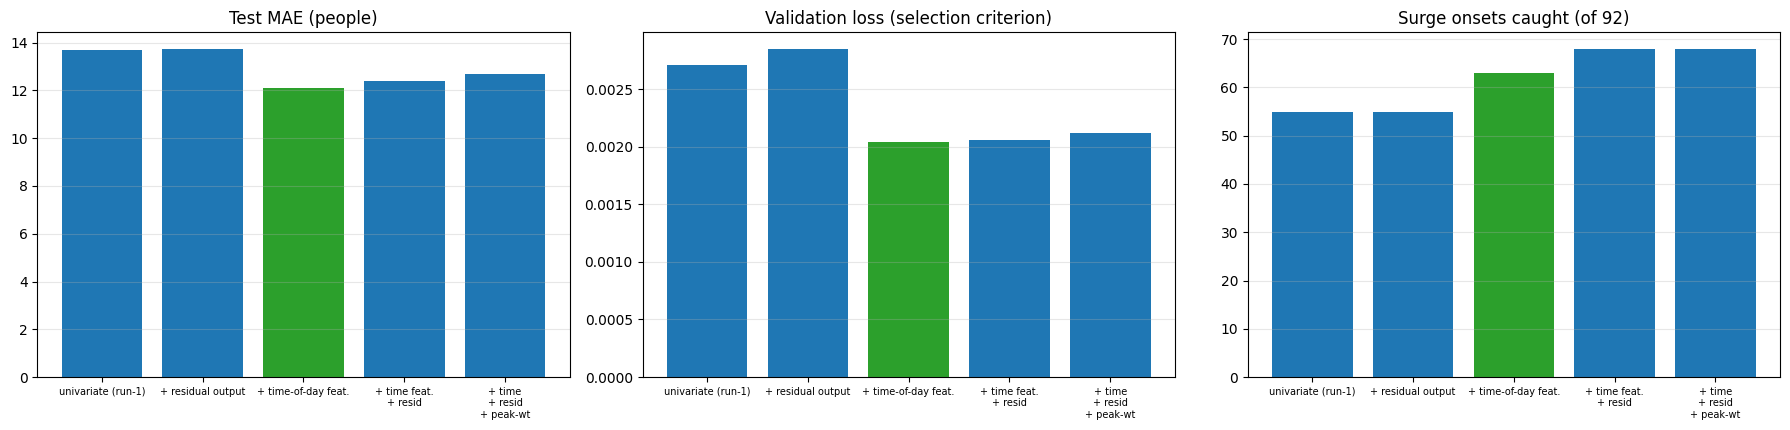

In [16]:
colors = {"CSRNet only (reactive)": "tab:red", "CSRNet + moving avg (3h)": "tab:orange",
          "CSRNet + seasonal (24h ago)": "tab:gray", "CSRNet + LSTM (predictive)": "tab:green"}
T = 168 if len(yt) >= 168 else len(yt)

# --- Figure A: LSTM loss + timeline
fig = plt.figure(figsize=(19, 6.2)); g = fig.add_gridspec(1, 3)
a0 = fig.add_subplot(g[0, 0])
for r in runs:
    if r is not BEST: a0.plot(r["hist"]["epoch"], r["hist"]["val_loss"], lw=1, ls="--", alpha=.5, label=f"val: {r['name']}")
a0.plot(lh["epoch"], lh["train_loss"], label="train (selected)", lw=2.4); a0.plot(lh["epoch"], lh["val_loss"], label="validation (selected)", lw=2.4)
a0.set(title=f"LSTM loss (normalised MSE) - selected: {BEST['name']}", xlabel="epoch", yscale="log"); a0.legend(fontsize=7); a0.grid(alpha=.3)
a1 = fig.add_subplot(g[0, 1:]); x = np.arange(T)
a1.axhspan(0, WARN, color="green", alpha=.08); a1.axhspan(WARN, CRIT, color="gold", alpha=.12); a1.axhspan(CRIT, max(yt.max(), 1) * 1.1, color="red", alpha=.08)
a1.plot(x, yt[:T], "k", lw=2.2, label="true next-hour count")
for k in ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]: a1.plot(x, preds[k][:T], color=colors[k], lw=1.6, label=k, alpha=.9)
on = np.where(((cur < CRIT) & (yt >= CRIT))[:T])[0]; a1.scatter(on, yt[on], marker="v", s=70, color="purple", zorder=5, label="surge onset")
a1.set(title="First 7 test days: true next-hour count vs forecasts", xlabel="hour", ylabel="people"); a1.legend(loc="upper right", fontsize=8); a1.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "lstm_loss_and_timeline.png", dpi=150); plt.show()

# --- Figure B: metric bars + scatters
fig, ax = plt.subplots(1, 4, figsize=(21, 4.6)); names = list(preds)
for a, m in zip(ax[:2], ["MAE", "RMSE"]):
    a.bar(range(4), table[m], color=[colors[k] for k in names]); a.set_xticks(range(4)); a.set_xticklabels([n.replace("CSRNet + ", "+").replace(" (", "\n(") for n in names], fontsize=8)
    a.set_title(f"{m} (people, lower is better)"); a.grid(alpha=.3, axis="y")
    for i, v in enumerate(table[m]): a.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
for a, k in zip(ax[2:], ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]):
    a.scatter(yt, preds[k], s=8, alpha=.5, color=colors[k]); lim = [0, max(yt.max(), preds[k].max()) * 1.05]; a.plot(lim, lim, "k--", lw=1)
    a.axvline(CRIT, color="r", lw=.6); a.axhline(CRIT, color="r", lw=.6)
    a.set(title=f"{k}  (R2={table.loc[k, 'R2']:.3f})", xlabel="true next-hour count", ylabel="forecast"); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "usecase_metrics.png", dpi=150); plt.show()

# --- Figure C: risk confusion matrices + early-warning counts
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4)); lab = ["Safe", "Warning", "Critical"]
ks = ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]
for a, k in zip(ax[:2], ks):
    cm = np.zeros((3, 3), int)
    for t, p in zip(level(yt), level(preds[k])): cm[t, p] += 1
    a.imshow(cm, cmap="Blues"); a.set(xticks=range(3), yticks=range(3), xticklabels=lab, yticklabels=lab, xlabel="forecast level", ylabel="true level", title=f"{k}\nrisk accuracy {rows[k]['risk_acc']:.2f}")
    for i in range(3):
        for j in range(3): a.text(j, i, cm[i, j], ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
w = 0.35; xs = np.arange(2)
ax[2].bar(xs - w/2, [rows[k]["onsets_caught"] for k in ks], w, label="surge onsets caught", color="tab:green")
ax[2].bar(xs + w/2, [rows[k]["false_alarms"] for k in ks], w, label="false alarms", color="tab:red")
ax[2].axhline(rows[ks[0]]["surge_onsets"], color="purple", ls="--", label=f"total onsets ({rows[ks[0]]['surge_onsets']})")
ax[2].set_xticks(xs); ax[2].set_xticklabels(["CSRNet only", "CSRNet + LSTM"]); ax[2].set_title("Early warning of critical crowds"); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(FIG_DIR / "usecase_risk.png", dpi=150); plt.show()

# --- Figure D: LSTM variant ablation
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4)); nm = [r["name"] for r in runs]; cl = ["tab:green" if r is BEST else "tab:blue" for r in runs]
for a, col, ttl in zip(ax, ["MAE", "val_loss", "onsets_caught"], ["Test MAE (people)", "Validation loss (selection criterion)", f"Surge onsets caught (of {rows[ks[0]]['surge_onsets']})"]):
    a.bar(range(len(nm)), abl[col].astype(float), color=cl); a.set_xticks(range(len(nm))); a.set_xticklabels([n.replace(" + ", "\n+ ").replace("features", "feat.") for n in nm], fontsize=7); a.set_title(ttl); a.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(FIG_DIR / "lstm_variants.png", dpi=150); plt.show()

In [17]:
# Export LSTM in the format backend/utils/model_registry.py reads (state_dict + config + scaler)
LSTM_CFG = dict(input_size=BEST["input_size"], hidden_size=64, num_layers=2, dropout=0.1, sequence_length=SEQ,
                residual=bool(BEST["resid"]), time_features=bool(BEST["feats"]), step_minutes=60)
scaler = {"method": "minmax", "min": lo, "max": hi}
torch.save({"state_dict": {k: v.cpu() for k, v in BEST["model"].state_dict().items()}, "config": LSTM_CFG, "scaler": scaler}, OUT_DIR / "lstm_model.pth")
json.dump(scaler, open(OUT_DIR / "lstm_scaler.json", "w"))
print("saved lstm_model.pth + lstm_scaler.json ->", LSTM_CFG, scaler)

saved lstm_model.pth + lstm_scaler.json -> {'input_size': 5, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'sequence_length': 24, 'residual': False, 'time_features': True, 'step_minutes': 60} {'method': 'minmax', 'min': 20.51638412475586, 'max': 539.0}


## 7. Backend compatibility check (mirrors `backend/utils/preprocessing.py`)

In [18]:
import datetime as dt, shutil
from PIL import Image
from torchvision import transforms
bt = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

sd = torch.load(OUT_DIR / "csrnet_model.pth", map_location="cpu")
chk = CSRNet(pretrained=False); chk.load_state_dict(sd, strict=True)            # strict load, like the backend
assert not any(k.startswith("module.") for k in sd), "state_dict has DataParallel prefix"
chk.to(DEVICE).eval(); diffs = []
for k, r in enumerate(test_by_part[POOL][:5]):
    x = bt(Image.open(r["path"]).convert("RGB")).unsqueeze(0).to(DEVICE)         # exactly what /predict-count does
    with torch.no_grad(): api_count = max(chk(x).sum().item(), 0)
    diffs.append(abs(api_count - P[POOL]["plain"][k]))
print("csrnet keys ok; max |backend-style count - notebook count| over 5 images:", round(max(diffs), 2))

def backend_time_feats(last_ts, seq, step_min=60):                               # pure-python copy of what the backend does
    rows = []
    for i in range(seq):
        t = last_ts - dt.timedelta(minutes=step_min * (seq - 1 - i)); h, d = t.hour, t.weekday()
        rows.append([math.sin(2*math.pi*h/24), math.cos(2*math.pi*h/24), math.sin(2*math.pi*d/7), math.cos(2*math.pi*d/7)])
    return np.array(rows, np.float32)

pl = torch.load(OUT_DIR / "lstm_model.pth", map_location="cpu"); cfg = pl["config"]
chk2 = CrowdLSTM(cfg["input_size"], cfg["hidden_size"], cfg["num_layers"], cfg["dropout"], cfg["residual"]); chk2.load_state_dict(pl["state_dict"], strict=True); chk2.eval()
window = Xt[0]; last_ts = ts[i_va + SEQ - 1].to_pydatetime()                      # what a client would send: past_counts + last_timestamp
z = norm(window).astype(np.float32)[:, None]
if cfg["time_features"]: z = np.concatenate([z, backend_time_feats(last_ts, SEQ)], 1)
with torch.no_grad(): f = float(denorm(chk2(torch.tensor(z).unsqueeze(0)).item()))
print(f"lstm keys ok; /predict-future style forecast = {f:.1f} (notebook = {p_lstm[0]:.1f})")

bm = OUT_DIR / "backend_models"; bm.mkdir(exist_ok=True)
for fn in ["csrnet_model.pth", "lstm_model.pth", "lstm_scaler.json"]: shutil.copy(OUT_DIR / fn, bm / fn)
summary = dict(csrnet=res, usecase=json.loads(table.join(risk).to_json(orient="index")), lstm_variants=json.loads(abl.to_json(orient="index")),
               selected_lstm=BEST["name"], lstm_config=LSTM_CFG, parts=PARTS, epochs=CFG["epochs"])
json.dump(summary, open(OUT_DIR / "results_summary.json", "w"), indent=2)
print("\nDownload folder for the backend ->", bm, [p.name for p in sorted(bm.iterdir())])

csrnet keys ok; max |backend-style count - notebook count| over 5 images: 0.02
lstm keys ok; /predict-future style forecast = 153.6 (notebook = 153.6)

Download folder for the backend -> /kaggle/working/backend_models ['csrnet_model.pth', 'lstm_model.pth', 'lstm_scaler.json']


In [19]:
# ============ FINAL CSVs: every test output + accuracy ============
# accuracy_pct = 100 - percentage error of that prediction (100 = exact); dataset-level accuracy = 100 - MAPE
def rlevel(v): return ["Safe", "Warning", "Critical"][int(np.digitize(v, [WARN, CRIT]))]
img_rows, summ = [], []
for p in PARTS:
    d = P[p]; recs = test_by_part[p]
    tta_better = res[f"Part {p} | optimised + flip-TTA"]["MAE"] <= res[f"Part {p} | optimised (EMA)"]["MAE"]
    final = d["tta"] if tta_better else d["plain"]
    for i, r in enumerate(recs):
        g_, f_ = d["gt"][i], final[i]; pe = abs(f_ - g_) / max(g_, 1) * 100
        img_rows.append(dict(part=p, image=r["name"], actual_count=g_, predicted_count=round(f_, 2), predicted_ema=round(d["plain"][i], 2),
                             predicted_flip_tta=round(d["tta"][i], 2), predicted_original_recipe=(round(d["base"][i], 2) if d["base"] is not None else np.nan),
                             abs_error=round(abs(f_ - g_), 2), pct_error=round(pe, 2), accuracy_pct=round(max(0, 100 - pe), 2),
                             within_10pct=int(pe <= 10), within_20pct=int(pe <= 20), actual_risk=rlevel(g_), predicted_risk=rlevel(f_)))
    m = metrics(final, d["gt"]); pe_all = np.abs(final - d["gt"]) / np.maximum(d["gt"], 1) * 100
    summ.append(dict(task=f"CSRNet count - Part {p} test ({len(recs)} images)", model="optimised" + (" + flip-TTA" if tta_better else " (EMA)"),
                     MAE=m["MAE"], RMSE=m["RMSE"], MAPE=m["MAPE"], accuracy_pct=100 - m["MAPE"], R2=m["R2"],
                     within_10pct=float((pe_all <= 10).mean() * 100), within_20pct=float((pe_all <= 20).mean() * 100),
                     risk_level_accuracy=float(np.mean([rlevel(a) == rlevel(b) for a, b in zip(d["gt"], final)]) * 100)))
pd.DataFrame(img_rows).to_csv(OUT_DIR / "final_test_predictions.csv", index=False)

# hour-by-hour forecast outputs on the chronological test windows
t_target = ts[i_va + SEQ:]
fc = pd.DataFrame({"timestamp": t_target, "csrnet_count_now": Xt[:, -1], "true_count_now": cur, "true_next_hour": yt})
for k, v in preds.items(): fc["forecast | " + k] = np.round(v, 2)
fc["true_risk_next_hour"] = [rlevel(v) for v in yt]; fc["lstm_risk_forecast"] = [rlevel(v) for v in p_lstm]
fc["lstm_abs_error"] = np.round(np.abs(p_lstm - yt), 2); fc["lstm_accuracy_pct"] = np.round(np.maximum(0, 100 - np.abs(p_lstm - yt) / np.maximum(yt, 1) * 100), 2)
fc.to_csv(OUT_DIR / "final_forecast_predictions.csv", index=False)
for k, v in preds.items():
    m = metrics(v, yt); pe_all = np.abs(v - yt) / np.maximum(yt, 1) * 100
    summ.append(dict(task=f"Next-hour forecast ({len(yt)} test hours)", model=k, MAE=m["MAE"], RMSE=m["RMSE"], MAPE=m["MAPE"], accuracy_pct=100 - m["MAPE"], R2=m["R2"],
                     within_10pct=float((pe_all <= 10).mean() * 100), within_20pct=float((pe_all <= 20).mean() * 100), risk_level_accuracy=rows[k]["risk_acc"] * 100))
final_summary = pd.DataFrame(summ).round(3); final_summary.to_csv(OUT_DIR / "final_accuracy_summary.csv", index=False)
print(final_summary.to_string(index=False))
print("\nsaved: final_test_predictions.csv (per image), final_forecast_predictions.csv (per hour), final_accuracy_summary.csv")

                                   task                       model    MAE    RMSE   MAPE  accuracy_pct    R2  within_10pct  within_20pct  risk_level_accuracy
CSRNet count - Part A test (182 images)        optimised + flip-TTA 71.115 116.188 16.725        83.275 0.892        41.209        68.681               88.462
CSRNet count - Part B test (316 images)        optimised + flip-TTA 12.704  24.219 10.187        89.813 0.935        64.241        91.456               92.089
   Next-hour forecast (1311 test hours)      CSRNet only (reactive) 35.158  54.106 38.745        61.255 0.536        26.697        53.852               71.854
   Next-hour forecast (1311 test hours)    CSRNet + moving avg (3h) 48.796  68.072 61.864        38.136 0.265        20.900        41.114               67.048
   Next-hour forecast (1311 test hours) CSRNet + seasonal (24h ago) 28.818  48.637 21.650        78.350 0.625        29.062        56.064               78.719
   Next-hour forecast (1311 test hours)  CSRNe

## 8. What to do with the outputs

1. Copy `backend_models/*` (`csrnet_model.pth`, `lstm_model.pth`, `lstm_scaler.json`) into the repo's `backend/models/`.
2. `final_test_predictions.csv` (every test image: actual vs predicted, error, accuracy), `final_forecast_predictions.csv` (every test hour) and `final_accuracy_summary.csv` are your result files.
3. Optionally copy `figures/*.png` to `docs/images/` (the root README embeds them) and `results_summary.json` for the numbers.
4. Restart the FastAPI server; `GET /health` should report `mode: live`.

**Still open (next steps):** real camera counts instead of the simulated stream · multi-step (2-6 h) forecasts with quantile loss for a confidence band · Bayesian/DM-Count losses and multi-scale heads for the densest scenes.